# Visualization of Laplace density and HLD 1D

ESS x1  | HLD: 1388   Prox-ULA: 265
Sparsity| HLD: 9.8%  Prox-ULA: 8.9%


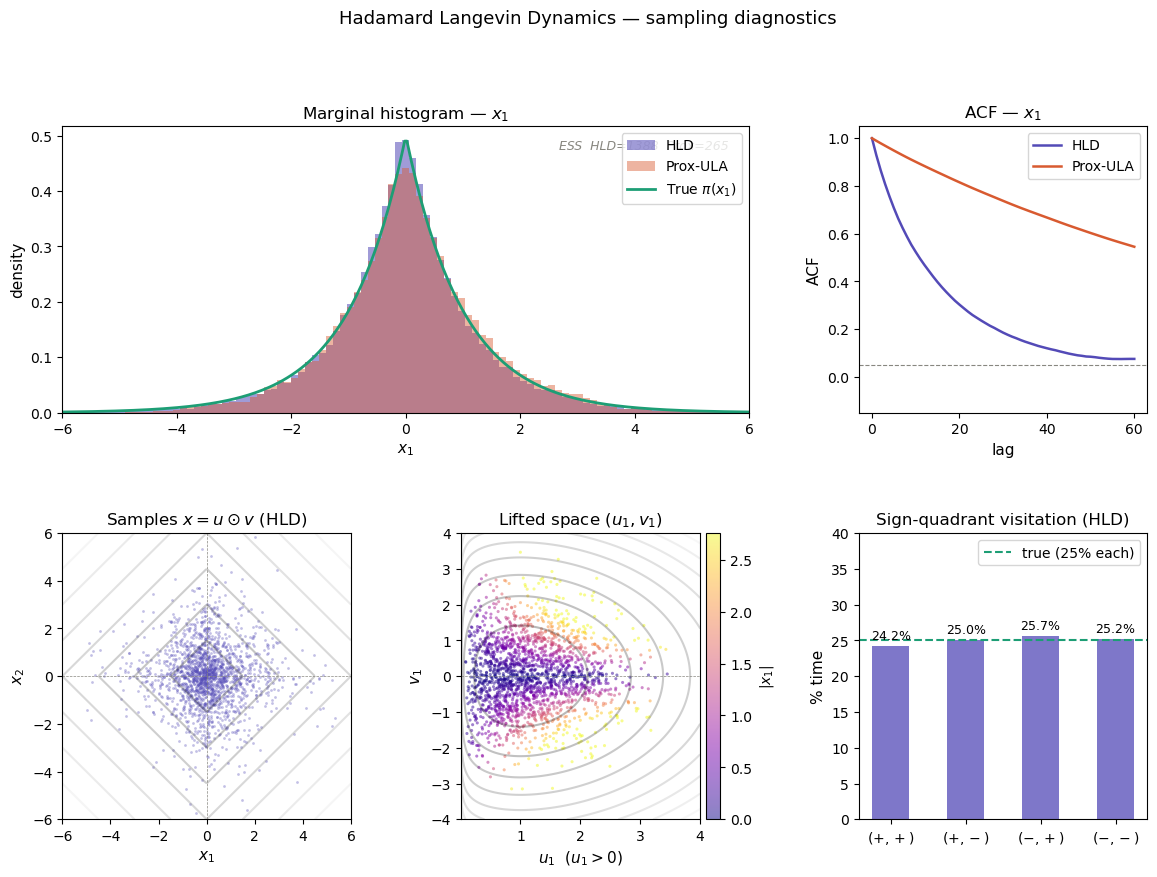

Saved hld_diagnostics.pdf and hld_diagnostics.png


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from context import samplers as samplers
np.random.seed(10)

# ── helpers ──────────────────────────────────────────────────────────────────

def soft(x, tau):
    return np.sign(x) * np.maximum(np.abs(x) - tau, 0)

def make_prox_kernel(tau, grad, lam, gamma, p, beta=1):
    grad_F = lambda x: grad(x) + (x - soft(x, lam * gamma)) / gamma
    return lambda z: samplers.one_step_langevin(z, p, grad_F, tau, beta)

def make_hadamard_kernel(tau, grad, lam, p, beta=1):
    return lambda z: samplers.one_step_hadamard(z, p, grad, tau, lam, beta)

def project_hadamard(z, p):
    return z[:p] * z[p:]

def acf(arr, max_lag=60):
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    mu = arr.mean()
    v = arr - mu
    den = (v ** 2).sum()
    return np.array([(v[:n-k] * v[k:]).sum() / den for k in range(max_lag + 1)])

def ess(arr, max_lag=None):
    arr = np.asarray(arr, dtype=float)
    if max_lag is None:
        max_lag = min(300, len(arr) // 3)
    a = acf(arr, max_lag)
    cutoff = np.argmax(a < 0.05)
    if cutoff == 0:
        cutoff = max_lag
    rho_sum = 1 + 2 * a[1:cutoff].sum()
    return len(arr) / rho_sum

# ── experiment setup ──────────────────────────────────────────────────────────

# Target: Laplace prior, no likelihood (pure l1)
p     = 2
lam   = 1.0
tau_h = 0.05   # HLD step size
tau_p = 0.01   # Prox-ULA step size (needs to be smaller)
gamma = 0.5 / lam*2  # Moreau envelope parameter for prox
gamma= .1
tau_p = gamma/5/(gamma+1)


grad_G = lambda x: np.zeros(p)   # pure Laplace prior, G = 0

N_samples  = 50_000
burn_in    = 10_000

# ── run HLD ──────────────────────────────────────────────────────────────────

hld_kernel = make_hadamard_kernel(tau_h, grad_G, lam, p)
init_hld   = np.concatenate([np.abs(np.random.randn(p)) + 0.5,
                              np.random.randn(p)])

# collect full (u,v) chain so we can plot in lifted space
uv_chain = samplers.generate_samples_x(hld_kernel, init_hld, N_samples, burn_in)
x_hld    = uv_chain[:, :p] * uv_chain[:, p:]   # project: x = u * v
u_chain  = uv_chain[:, :p]
v_chain  = uv_chain[:, p:]

# ── run Prox-ULA ─────────────────────────────────────────────────────────────

prox_kernel = make_prox_kernel(tau_p, grad_G, lam, gamma, p)
init_prox   = np.random.randn(p)
x_prox      = samplers.generate_samples_x(prox_kernel, init_prox, N_samples, burn_in)

# ── diagnostics ──────────────────────────────────────────────────────────────

ess_h = ess(x_hld[:, 0])
ess_p = ess(x_prox[:, 0])
sparsity_h = np.mean(np.abs(x_hld[:, 0]) < 0.1) * 100
sparsity_p = np.mean(np.abs(x_prox[:, 0]) < 0.1) * 100

print(f"ESS x1  | HLD: {ess_h:.0f}   Prox-ULA: {ess_p:.0f}")
print(f"Sparsity| HLD: {sparsity_h:.1f}%  Prox-ULA: {sparsity_p:.1f}%")

acf_h = acf(x_hld[:, 0], 60)
acf_p = acf(x_prox[:, 0], 60)

# ── plotting ─────────────────────────────────────────────────────────────────

PURPLE = "#534AB7"
CORAL  = "#D85A30"
TEAL   = "#1D9E75"
GRAY   = "#888780"

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── 1. Marginal histogram (x1) ────────────────────────────────────────────

ax1 = fig.add_subplot(gs[0, :2])

bins = np.linspace(-6, 6, 100)
ax1.hist(x_hld[:, 0],  bins=bins, density=True,
         color=PURPLE, alpha=0.55, label="HLD")
ax1.hist(x_prox[:, 0], bins=bins, density=True,
         color=CORAL, alpha=0.45, label="Prox-ULA")

xs_true = np.linspace(-6, 6, 300)
ax1.plot(xs_true, lam / 2 * np.exp(-lam * np.abs(xs_true)),
         color=TEAL, lw=2, label=r"True $\pi(x_1)$")

ax1.set_xlabel(r"$x_1$", fontsize=11)
ax1.set_ylabel("density", fontsize=11)
ax1.set_title(r"Marginal histogram — $x_1$", fontsize=12)
ax1.legend(fontsize=10)
ax1.set_xlim(-6, 6)

# annotation
ax1.text(0.97, 0.92,
         f"ESS  HLD={ess_h:.0f}  Prox={ess_p:.0f}",
         transform=ax1.transAxes, ha="right", fontsize=9,
         color=GRAY, style="italic")

# ── 2. ACF ───────────────────────────────────────────────────────────────────




ax2 = fig.add_subplot(gs[0, 2])
lags = np.arange(len(acf_h))
ax2.plot(lags, acf_h, color=PURPLE, lw=1.8, label="HLD")
ax2.plot(lags, acf_p, color=CORAL,  lw=1.8, label="Prox-ULA")
ax2.axhline(0.05, color=GRAY, lw=0.8, ls="--")
ax2.set_xlabel("lag", fontsize=11)
ax2.set_ylabel("ACF", fontsize=11)
ax2.set_title(r"ACF — $x_1$", fontsize=12)
ax2.set_ylim(-0.15, 1.05)
ax2.legend(fontsize=10)

# ── 3. x = u⊙v scatter ───────────────────────────────────────────────────────

xx, yy = np.meshgrid(np.linspace(-6,6,200), np.linspace(-6,6,200))
Z_xy = np.abs(xx) +np.abs(yy)

ax3 = fig.add_subplot(gs[1, 0])
idx = np.random.choice(N_samples, size=min(2000, N_samples), replace=False)
ax3.contour(xx, yy, ( -Z_xy), levels=10, cmap='gray_r', alpha=0.3)

ax3.scatter(x_hld[idx, 0], x_hld[idx, 1],
            s=4, color=PURPLE, alpha=0.35, linewidths=0)
ax3.set_xlabel(r"$x_1$", fontsize=11)
ax3.set_ylabel(r"$x_2$", fontsize=11)
ax3.set_title(r"Samples $x = u \odot v$ (HLD)", fontsize=12)
ax3.axhline(0, color=GRAY, lw=0.5, ls="--")
ax3.axvline(0, color=GRAY, lw=0.5, ls="--")
ax3.set_xlim(-6, 6)
ax3.set_ylim(-6, 6)


# ── 4. Lifted space (u1, v1) coloured by |x1| ────────────────────────────────
uu, vv = np.meshgrid(np.linspace(0.001,4,200), np.linspace(-4,4,200))
X = uu * vv
Z_uv = 1*(  0.5* lam*uu**2 + 0.5* lam*vv**2) - np.log(uu)


ax4 = fig.add_subplot(gs[1, 1])
x1_abs = np.abs(x_hld[idx, 0])
norm   = Normalize(vmin=0, vmax=np.percentile(x1_abs, 95))
sc = ax4.scatter(u_chain[idx, 0], v_chain[idx, 0],
                 c=x1_abs, cmap="plasma", s=5, alpha=0.5,
                 norm=norm, linewidths=0)
ax4.contour(uu, vv, ( -Z_uv), levels=10, cmap='gray_r', alpha=0.3)

plt.colorbar(sc, ax=ax4, label=r"$|x_1|$", pad=0.02)
ax4.set_xlabel(r"$u_1$  $(u_1 > 0)$", fontsize=11)
ax4.set_ylabel(r"$v_1$", fontsize=11)
ax4.set_title(r"Lifted space $(u_1, v_1)$", fontsize=12)
ax4.axhline(0, color=GRAY, lw=0.5, ls="--")

# ── 5. Sign-quadrant visitation ───────────────────────────────────────────────

ax5 = fig.add_subplot(gs[1, 2])
signs = np.sign(x_hld)
quadrants = {
    r"$(+,+)$": np.mean((signs[:, 0] > 0) & (signs[:, 1] > 0)),
    r"$(+,-)$": np.mean((signs[:, 0] > 0) & (signs[:, 1] < 0)),
    r"$(-,+)$": np.mean((signs[:, 0] < 0) & (signs[:, 1] > 0)),
    r"$(-,-)$": np.mean((signs[:, 0] < 0) & (signs[:, 1] < 0)),
}
labels = list(quadrants.keys())
vals   = [v * 100 for v in quadrants.values()]
bars = ax5.bar(labels, vals, color=PURPLE, alpha=0.75, width=0.5)
ax5.axhline(25, color=TEAL, lw=1.5, ls="--", label="true (25% each)")
ax5.set_ylabel("% time", fontsize=11)
ax5.set_title("Sign-quadrant visitation (HLD)", fontsize=12)
ax5.set_ylim(0, 40)
ax5.legend(fontsize=10)
for bar, v in zip(bars, vals):
    ax5.text(bar.get_x() + bar.get_width() / 2, v + 0.5,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

# ── save ──────────────────────────────────────────────────────────────────────

fig.suptitle("Hadamard Langevin Dynamics — sampling diagnostics", fontsize=13, y=1.01)
plt.savefig("hld_diagnostics.pdf", bbox_inches="tight")
plt.savefig("hld_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hld_diagnostics.pdf and hld_diagnostics.png")